In [26]:
from emulator.interpolator import util
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats

# Obtain samples
param_names = ['log_lsun', 't_exp', 'X', 'Z', 'n', 'rho_0']
limits = [(8, 9), (10, 23), (0.55, 0.95), (5e-4, 5e-2), (6, 14), (7e-15, 8e-14)]
n = 5000
record_quantile = False

distribs = []
for min, max in limits:
    distribs.append(scipy.stats.uniform(min, max - min))

def prior_transform(cube):
    params = [distribs[i].ppf(cube[i]) for i in range(len(cube))]
    return params

# Create DataFrame
data = {}
for param in param_names:
    data[param] = []
    if record_quantile:
        data[param + '_u'] = []

for i in range(n):
    cube = np.random.rand(len(param_names))
    params = prior_transform(cube)
    for i, value in enumerate(params):
        param = param_names[i]
        data[param].append(value)
        if record_quantile:
            data[param + '_u'].append(cube[i])

df = pd.DataFrame(data)
df.index.name = 'id'
v_phot = util.calc_v_phot(t_exp=df['t_exp'].values, X=df['X'].values, n=df['n'].values, rho_0=df['rho_0'].values)
mask = (v_phot > 5000) & (v_phot < 8000)
df = df[mask]
df.reset_index(drop=True, inplace=True)
df.index.name = 'id'

df.to_csv('grid.csv')

In [21]:
print(limits[-1])
print(df['rho_0'].min())
print(df['rho_0'].max())

(7e-15, 8e-14)
9.217225727128303e-15
7.493677610951021e-14


604.8062968015572 41842.41158509038
772


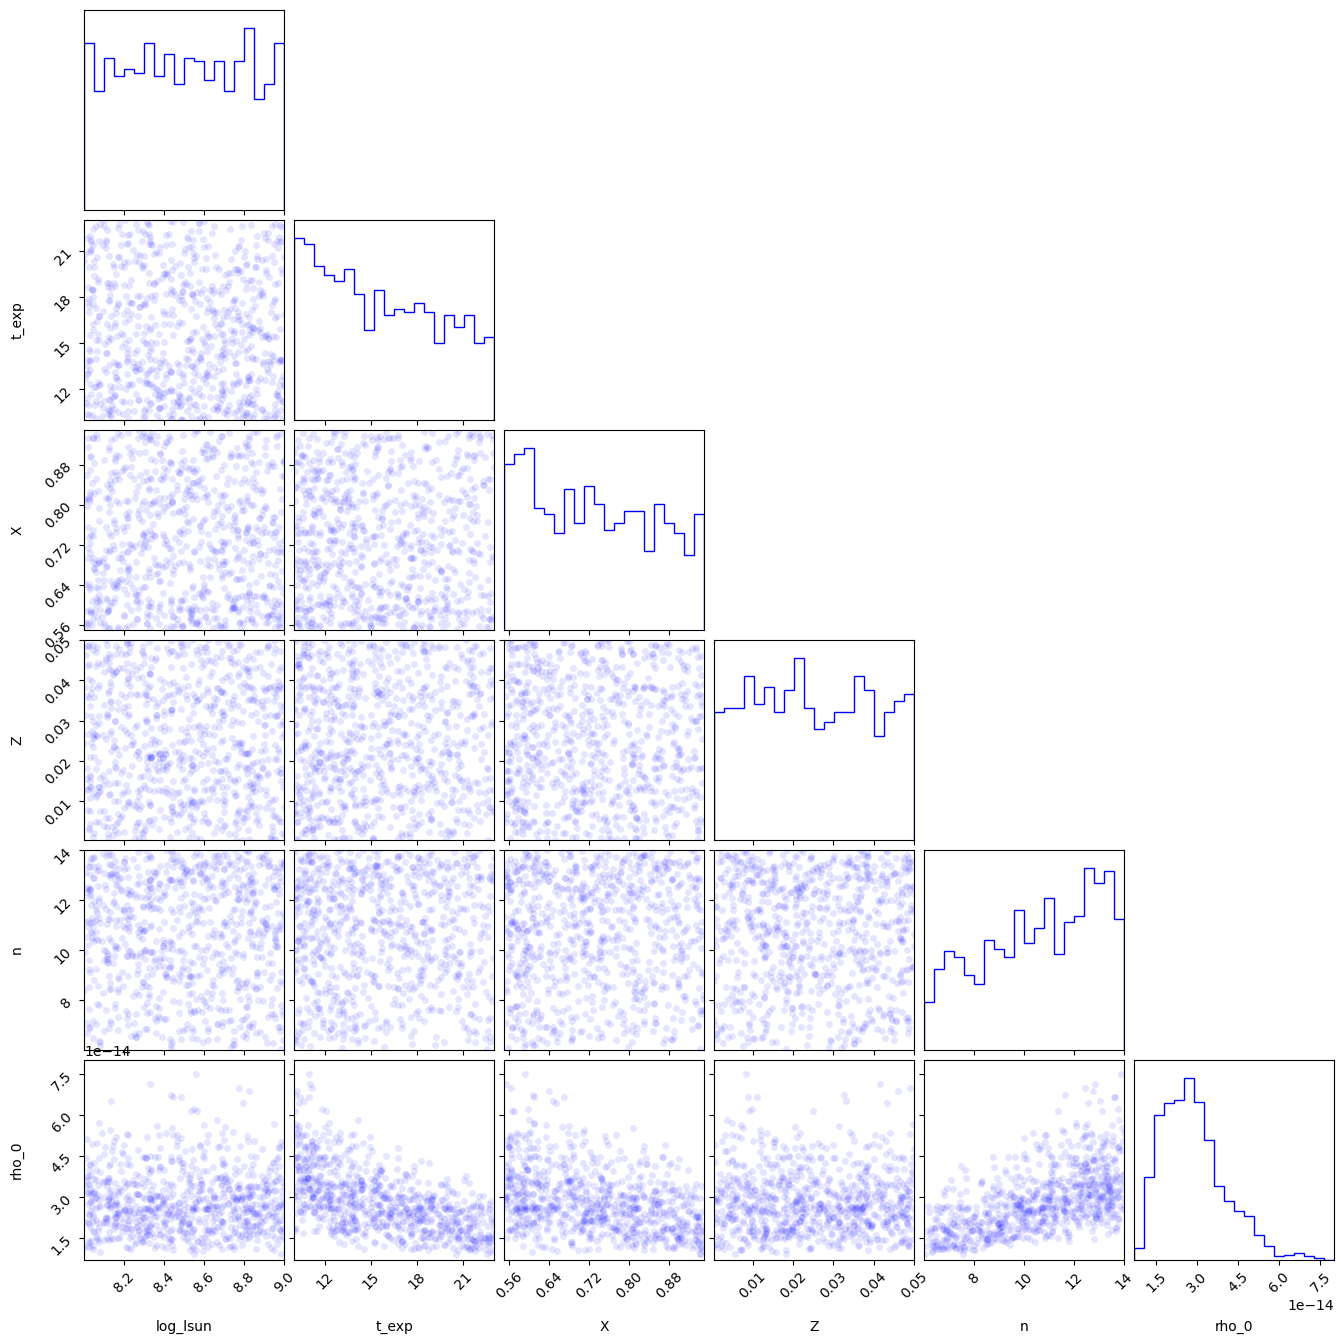

In [18]:
print(v_phot.min(), v_phot.max())
print(len(df))
import corner

fig = corner.corner(
    df[param_names].values,
    labels=param_names,
    range=limits,
    bins = 20,
    color='blue',
    plot_contours=False,
    plot_datapoints=True,
    plot_density=False,
    data_kwargs={'ms': 5}
)

In [ ]:
import pandas as pd
import numpy as np

# Seed samples for noise variation tests
n = 1000
seeds = np.random.randint(low=10000000, high=100000000, size=n)
virtual_packets = [3]*int(n/2) + [6]*int(n/2)

df = pd.DataFrame({'seed': seeds, 'virtual_packets': virtual_packets})
df.index.name = 'id'
df.to_csv('grid.csv')
